# Quality Control and Cleaning of Synthetic SQuAD v2 Datasets

- **Author:** Lenin G. Falconí
- **Date:** 2026-08-28
- **Project:** Extension of the Springer chapter — *Leveraging Transformer Models for Extractive Question Answering in Criminal Report Analysis*

## Objective

Automatically and reproducibly evaluate the quality of two synthetic extractive question-answering (SQuAD v2) datasets generated over the **same 15,000 robbery-report contexts** and the **same 5 questions per context**:

- **Gemma 3 1B** (`squadv2_gemma-3-1b.jsonl`)
- **Qwen 2.5 3B** (`squadv2_qwen2.5-3b.jsonl`)

The protocol measures: structural integrity, extractive validity (literal span + offsets), abstention consistency, span distribution/usefulness, inter-generator agreement, and produces a **final cleaned dataset** in SQuAD v2 format ready for fine-tuning a Spanish BERT/BETO.

> **Note on the sentinel:** the value `RESPUESTA_NO_ENCONTRADA` is used during generation to avoid collisions with context text. In the final training dataset it must be converted to `is_impossible: true` with empty answers, never left as `answer_text`.


## Configuration

Adjust the paths to each model's JSONL files and to the worker logs. The Gemma and Qwen worker logs are read from `logs_20260828_165621/logs/` using one pattern per model. If the Qwen file is not present on this machine, the notebook runs all single-model phases and skips the agreement/merging sections with a clear message.


## Methodology

1. **Generation**: two models generate 5 questions per context for the same 15,000 contexts (75,000 expected `(context_id, question)` pairs per model).
2. **Structural QC**: verify JSON parseability, required fields, valid labels, uniqueness, and 5-questions-per-context.
3. **Extractive validity**: recompute and validate answer offsets; classify each row with a `qc_status` label (see glossary below).
4. **Semantic heuristics**: flag suspicious spans by question type (time, date, value, place, objects).
5. **Abstention consistency**: check sentinel/label coherence and measure answer vs abstention rates.
6. **Span distribution**: analyze answer length, duplicates, and over-long answers.
7. **Inter-generator agreement**: compare Gemma vs Qwen on the same `(context_id, question)` pairs.
8. **Final datasets**: build `strict`, `expanded`, `uncertain` splits per model and an optional merged dataset.
9. **Human audit**: export a stratified sample for manual review.


In [1]:
import os
import re
import json
import glob
import unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    from tqdm.auto import tqdm
    HAS_TQDM = True
except ImportError:
    def tqdm(iterable=None, **kwargs):
        return iterable if iterable is not None else None
    HAS_TQDM = False


def progress_apply(df, func, axis=1, desc="Processing"):
    """DataFrame.apply with a tqdm progress bar when tqdm is available."""
    if HAS_TQDM:
        tqdm.pandas(desc=desc)
        return df.progress_apply(func, axis=axis)
    return df.apply(func, axis=axis)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 200)

# ------------------------------------------------------------------
# Paths to the generated datasets
# ------------------------------------------------------------------
DATA_DIR = "./dataset/dataset_squadv2_M2"
DATASET_PATHS = {
    "gemma": os.path.join(DATA_DIR, "squadv2_gemma-3-1b.jsonl"),
    "qwen":  os.path.join(DATA_DIR, "squadv2_qwen2.5-3b.jsonl"),
}

# If you only have the attached Gemma file locally, override here:
ATTACHED_GEMMA = "squadv2_gemma-3-1b.jsonl"  # attached file in the workspace
if os.path.exists(ATTACHED_GEMMA) and not os.path.exists(DATASET_PATHS["gemma"]):
    DATASET_PATHS["gemma"] = ATTACHED_GEMMA

# ------------------------------------------------------------------
# Worker logs (for processing-time analysis)
# ------------------------------------------------------------------
# The parser reads base worker logs plus any resume subdirectory
# (e.g. <model>_resume_*/<model>_worker_*.log) so either model can be
# interrupted and resumed without code changes.
WORKER_LOG_DIR = "logs_20260830_070622/logs"     # worker logs from the 2026-08-30 M2 build
WORKER_LOG_PATTERNS = {
    "gemma": [
        "gemma-3-1b-it_worker_*.log",
        "gemma-3-1b-it_resume_*/gemma-3-1b-it_worker_*.log",
    ],
    "qwen": [
        "qwen2.5-3b-instruct_worker_*.log",
        "qwen2.5-3b-instruct_resume_*/qwen2.5-3b-instruct_worker_*.log",
    ],
}

# ------------------------------------------------------------------
# Labels for publication (English display names)
# ------------------------------------------------------------------
QC_STATUS_EN = {
    "no_answer_clean": "clean_no_answer (impossible + sentinel)",
    "no_answer_empty": "empty_no_answer (impossible + empty text)",
    "no_answer_free_text": "free_text_no_answer (impossible + free text not in context)",
    "imposible_but_span_present": "impossible_but_span_present (span found in context)",
    "respondido_no_answer": "answered_no_answer (answered but no answer text)",
    "extractive_valid_unique": "valid_unique_span (literal, single occurrence)",
    "extractive_ambiguous": "ambiguous_span (literal, multiple occurrences)",
    "extractive_only_normalized": "normalized_only_span (match after normalization)",
    "non_extractive_or_hallucinated": "non_extractive_or_hallucinated (span not found)",
}
QKIND_EN = {"hora": "time", "fecha": "date", "valor": "value", "lugar": "place", "objetos": "objects", "otro": "other"}

# ------------------------------------------------------------------
# Experiment parameters
# ------------------------------------------------------------------
N_CONTEXTS = 20_000
QUESTIONS_PER_CONTEXT = 5
EXPECTED_PAIRS = N_CONTEXTS * QUESTIONS_PER_CONTEXT   # 100,000
NO_ANSWER_SENTINEL = "RESPUESTA_NO_ENCONTRADA"

# ------------------------------------------------------------------
# Output directories
# ------------------------------------------------------------------
OUT_DIR = "out_qc_M2"
os.makedirs(OUT_DIR, exist_ok=True)

# Models present
MODELS = [m for m, p in DATASET_PATHS.items() if os.path.exists(p)]
print("Models found:", MODELS)
print("Paths:", {m: DATASET_PATHS[m] for m in MODELS})
if not MODELS:
    raise FileNotFoundError("No dataset files found. Adjust DATASET_PATHS.")


Models found: ['gemma', 'qwen']
Paths: {'gemma': './dataset/dataset_squadv2_M2/squadv2_gemma-3-1b.jsonl', 'qwen': './dataset/dataset_squadv2_M2/squadv2_qwen2.5-3b.jsonl'}


/home/leningfe/miniforge3/envs/pyt-eqa-fge/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Phase 0 — Loading and initial exploration

Each record has the fields: `context`, `question`, `answer_start`, `answer_end`, `impossible_find_answer` (bool), `answer_text`, `is_impossible` ("respondido"/"imposible"), `context_id`.


In [2]:
def load_jsonl(path):
    records = []
    with open(path, "r", encoding="utf-8") as f:
        total_lines = sum(1 for _ in f)
    with open(path, "r", encoding="utf-8") as f:
        for i, line in enumerate(tqdm(f, total=total_lines, desc=f"Loading {os.path.basename(path)}", unit="lines")):
            line = line.strip()
            if not line:
                continue
            try:
                records.append(json.loads(line))
            except json.JSONDecodeError:
                records.append({"_parse_error": True, "_raw_line_index": i})
    return pd.DataFrame(records)

frames = {m: load_jsonl(DATASET_PATHS[m]) for m in MODELS}

for m in MODELS:
    df = frames[m]
    parse_err = df.get("_parse_error", pd.Series(dtype=bool)).sum() if "_parse_error" in df else 0
    print(f"=== {m} ===")
    print(f"Rows: {len(df)} | Expected: {EXPECTED_PAIRS} | "
          f"Completeness: {len(df)/EXPECTED_PAIRS*100:.2f}% | Invalid JSON: {int(parse_err)}")
    print(df.columns.tolist())
    print(df.head(3).to_string())
    print()


Loading squadv2_qwen2.5-3b.jsonl: 100%|██████████| 100000/100000 [00:04<00:00, 22839.46lines/s]


=== gemma ===
Rows: 100000 | Expected: 100000 | Completeness: 100.00% | Invalid JSON: 0
['context', 'question', 'answer_start', 'answer_end', 'impossible_find_answer', 'answer_text', 'is_impossible', 'context_id']
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        context                             question  answer_start  answer_end  impossible_find_answer              answer_text is_impossible context_id
0  es el caso señor fiscal que la madrugada del domingo 0

In [3]:
# Standardize types and labels for both models
def normalize_df(df):
    df = df.copy()
    if "_parse_error" in df.columns:
        df = df[df["_parse_error"] != True].drop(columns=[c for c in ["_parse_error","_raw_line_index"] if c in df.columns])
    df["answer_text"] = df["answer_text"].fillna("").astype(str)
    df["context"] = df["context"].fillna("").astype(str)
    df["question"] = df["question"].fillna("").astype(str)
    df["is_impossible"] = df["is_impossible"].astype(str).str.strip().str.lower()
    # impossible_find_answer arrives as bool or string; normalize to bool
    df["impossible_find_answer"] = df["impossible_find_answer"].astype(str).str.strip().str.lower().isin(["true","1","yes"])
    return df.reset_index(drop=True)

frames = {m: normalize_df(df) for m, df in frames.items()}

for m in MODELS:
    df = frames[m]
    print(f"--- {m} ---")
    print("is_impossible:", df["is_impossible"].value_counts(dropna=False).to_dict())
    print("impossible_find_answer:", df["impossible_find_answer"].value_counts(dropna=False).to_dict())
    print()


--- gemma ---
is_impossible: {'respondido': 56163, 'imposible': 43837}
impossible_find_answer: {False: 56163, True: 43837}

--- qwen ---
is_impossible: {'respondido': 61340, 'imposible': 38660}
impossible_find_answer: {False: 61340, True: 38660}



## Phase 1 — Structural integrity

Measures the technical reliability of the pipeline: parseable JSON, required fields present, valid labels, uniqueness of `(context_id, question)`.


In [4]:
REQUIRED_FIELDS = ["context", "question", "answer_text", "is_impossible", "context_id"]
VALID_IS_IMPOSSIBLE = {"respondido", "imposible"}

def structural_report(df):
    n = len(df)
    rep = {}
    rep["rows"] = n
    rep["invalid_json"] = 0  # filtered out during loading
    rep["required_fields_ok"] = int(df[REQUIRED_FIELDS].notna().all(axis=1).sum())
    rep["valid_label"] = int(df["is_impossible"].isin(VALID_IS_IMPOSSIBLE).sum())
    rep["duplicate_context_question"] = int(df.duplicated(subset=["context_id","question"]).sum())
    # Each context should have exactly 5 questions
    q_per_ctx = df.groupby("context_id")["question"].nunique()
    rep["contexts_with_5_questions"] = int((q_per_ctx == 5).sum())
    rep["unique_contexts"] = int(df["context_id"].nunique())
    rep["unique_questions"] = int(df["question"].nunique())
    rep["valid_schema_rate_%"] = rep["valid_label"] / n * 100 if n else 0
    return pd.Series(rep)

# Vertical table: metrics as rows, models as columns (publication-friendly)
struct_summary = pd.DataFrame({m: structural_report(df) for m, df in frames.items()})
struct_summary


,gemma,qwen
rows,100000.0,100000.0
invalid_json,0.0,0.0
required_fields_ok,100000.0,100000.0
valid_label,100000.0,100000.0
duplicate_context_question,0.0,0.0
contexts_with_5_questions,20000.0,20000.0
unique_contexts,20000.0,20000.0
unique_questions,5.0,5.0
valid_schema_rate_%,100.0,100.0


In [5]:
for m in MODELS:
    print(f"=== Questions present in {m} ===")
    print(frames[m]["question"].value_counts(dropna=False))
    print()


=== Questions present in gemma ===
question
¿Qué objetos fueron robados?                                                 20000
¿En qué fecha ocurrió el incidente?                                          20000
¿A qué hora sucedió el robo?                                                 20000
¿En qué dirección o entre qué calles sucedió el robo, suceso o incidente?    20000
¿Qué valor en dólares tenían los objetos sustraídos o robados?               20000
Name: count, dtype: int64

=== Questions present in qwen ===
question
¿Qué objetos fueron robados?                                                 20000
¿En qué fecha ocurrió el incidente?                                          20000
¿A qué hora sucedió el robo?                                                 20000
¿En qué dirección o entre qué calles sucedió el robo, suceso o incidente?    20000
¿Qué valor en dólares tenían los objetos sustraídos o robados?               20000
Name: count, dtype: int64



## Phase 2 — Extractive validity

Fundamental rule: an answer marked as `respondido` must be a **literal span of the context** with verifiable offsets. **We do not trust the generated `answer_start`/`answer_end`**: we recompute and validate them.

SQuAD v2 sentinel conversion:
- `imposible` + sentinel → `is_impossible: true`, empty answers.
- `respondido` but the answer does not appear in the context → marked as `non_extractive_or_hallucinated`; **not** automatically converted to `imposible`.


### Glossary of extractive-validity statuses

Each row receives one `qc_status` label:

- **`clean_no_answer`** (`no_answer_clean`): labelled `imposible` and `answer_text` is the sentinel `RESPUESTA_NO_ENCONTRADA` → a clean abstention; becomes `is_impossible: true` with empty answers.
- **`empty_no_answer`** (`no_answer_empty`): labelled `imposible` and `answer_text` is empty → also a clean abstention.
- **`free_text_no_answer`** (`no_answer_free_text`): labelled `imposible` but the model wrote free text that is **not** a literal span of the context → still treated as abstention in the expanded set.
- **`impossible_but_span_present`**: labelled `imposible` but `answer_text` **is** a literal span → suspicious; the model may have found a real answer and mislabelled it. Goes to `uncertain`.
- **`answered_no_answer`** (`respondido_no_answer`): labelled `respondido` but `answer_text` is empty or the sentinel → inconsistent.
- **`valid_unique_span`** (`extractive_valid_unique`): labelled `respondido`, the answer appears exactly once in the context, and the provided offset matches → high-confidence positive.
- **`ambiguous_span`** (`extractive_ambiguous`): labelled `respondido`, the same literal answer appears more than once in the context → valid but offset is ambiguous; we use the first occurrence.
- **`normalized_only_span`** (`extractive_only_normalized`): the answer is not a literal match but matches after Unicode/whitespace normalisation → weaker positive.
- **`non_extractive_or_hallucinated`**: labelled `respondido` but the answer is not found in the context even after normalisation → likely hallucination; goes to `uncertain`, never auto-converted to `imposible`.


In [6]:
def normalize_text(s):
    '''Unicode normalization + whitespace handling for span comparison (does not replace the original text).'''
    if s is None:
        return ""
    s = str(s).lower()
    s = unicodedata.normalize("NFKC", s)
    s = "".join(ch for ch in unicodedata.normalize("NFD", s) if unicodedata.category(ch) != "Mn")
    s = s.replace("“", "\"").replace("”", "\"").replace("’", "'").replace("‘", "'")
    s = re.sub(r"\s+", " ", s)
    s = re.sub(r"\s+([.,;:!?])", r"\1", s)
    return s.strip()

def find_all_occurrences(haystack, needle):
    '''Return all zero-based positions where needle appears in haystack.'''
    positions = []
    if not needle:
        return positions
    start = 0
    while True:
        idx = haystack.find(needle, start)
        if idx == -1:
            break
        positions.append(idx)
        start = idx + 1
    return positions


In [7]:
def extractive_validity(df, model):
    df = df.copy()
    n = len(df)
    answer_text = df["answer_text"].astype(str).values
    context = df["context"].astype(str).values
    labels = df["is_impossible"].values

    literal_match = np.zeros(n, dtype=bool)
    norm_match = np.zeros(n, dtype=bool)
    match_count = np.zeros(n, dtype=int)
    recomputed_start = np.full(n, -1, dtype=int)
    provided_offset_valid = np.zeros(n, dtype=bool)
    status = np.empty(n, dtype=object)

    for i in tqdm(range(n), desc=f"extractive_validity ({model})", unit="rows"):
        ans = answer_text[i].strip()
        ctx = context[i]
        norm_ans = normalize_text(ans)
        norm_ctx = normalize_text(ctx)

        if labels[i] == "imposible":
            # Non-answerable case: is_impossible defines the no-answer class.
            # answer_text is discarded in the final SQuAD v2 conversion.
            if ans == NO_ANSWER_SENTINEL:
                status[i] = "no_answer_clean"
            elif ans == "":
                status[i] = "no_answer_empty"
            else:
                # The model wrote free text instead of the sentinel.
                # If that text IS a span of the context, the model may have
                # found an answer but mislabelled it as impossible.
                occ = find_all_occurrences(ctx, ans)
                if len(occ) >= 1:
                    status[i] = "imposible_but_span_present"
                else:
                    status[i] = "no_answer_free_text"
            continue

        # answered
        if ans == "" or ans == NO_ANSWER_SENTINEL:
            # marked answered but did not provide a real answer
            status[i] = "respondido_no_answer"
            continue

        # exact literal match
        occ = find_all_occurrences(ctx, ans)
        if len(occ) >= 1:
            literal_match[i] = True
            match_count[i] = len(occ)
            recomputed_start[i] = occ[0]
            # verify provided offset if present
            prov_start = df["answer_start"].iloc[i] if "answer_start" in df else np.nan
            prov_end = df["answer_end"].iloc[i] if "answer_end" in df else np.nan
            try:
                ps = int(prov_start); pe = int(prov_end)
                if ctx[ps:pe] == ans:
                    provided_offset_valid[i] = True
            except Exception:
                provided_offset_valid[i] = False
            if len(occ) == 1:
                status[i] = "extractive_valid_unique"
            else:
                status[i] = "extractive_ambiguous"
            continue

        # match only after normalization
        occ_n = find_all_occurrences(norm_ctx, norm_ans)
        if len(occ_n) >= 1:
            norm_match[i] = True
            status[i] = "extractive_only_normalized"
            continue

        status[i] = "non_extractive_or_hallucinated"

    df["literal_match"] = literal_match
    df["norm_match"] = norm_match
    df["literal_match_count"] = match_count
    df["recomputed_answer_start"] = recomputed_start
    df["provided_offset_valid"] = provided_offset_valid
    df["qc_status"] = status
    df["answer_words"] = df["answer_text"].str.split().str.len()
    return df

frames = {m: extractive_validity(df, m) for m, df in frames.items()}
for m in MODELS:
    print(f"=== {m} — QC status ===")
    counts = frames[m]["qc_status"].value_counts(dropna=False)
    counts.index = [QC_STATUS_EN.get(i, i) for i in counts.index]
    print(counts)
    print()


extractive_validity (qwen): 100%|██████████| 100000/100000 [00:30<00:00, 3290.03rows/s]


=== gemma — QC status ===
valid_unique_span (literal, single occurrence)                 51426
free_text_no_answer (impossible + free text not in context)    43446
ambiguous_span (literal, multiple occurrences)                  4737
clean_no_answer (impossible + sentinel)                          390
impossible_but_span_present (span found in context)                1
Name: count, dtype: int64

=== qwen — QC status ===
valid_unique_span (literal, single occurrence)                 60090
clean_no_answer (impossible + sentinel)                        29008
free_text_no_answer (impossible + free text not in context)     9619
ambiguous_span (literal, multiple occurrences)                  1250
empty_no_answer (impossible + empty text)                         33
Name: count, dtype: int64



### Semantic heuristics by question type (v2)

Extractive validity does **not** guarantee that the span actually answers the question. The v2 heuristic is data-driven and context-aware:

- Expanded time/date/money patterns to capture Qwen/Gemma variants (`del`, word months, `12 00`, `madrugada`, etc.).
- Expanded object/location hints (moto, vehículo, tablet, televisor, etc.).
- Context-aware checks: for `hora`, flags times associated with discovery/parking markers (`estacionado`, `al retornar`, `me percaté`, etc.); for `objetos`, flags when the context mentions notably more object hints than the answer.
- Flags distance markers or vague locations for `lugar`, and non-informative/very short answers for `objetos`.

`semantic_heuristic_flag` now uses the improved v2 flag; the old v1 flag is kept as `semantic_flag_v1` for comparison.


In [8]:
TIME_RE  = re.compile(r"\b\d{1,2}h\d{2}\b|\b\d{1,2}:\d{2}\b|\b\d{1,2}\s*(am|pm|de la mañana|de la tarde|de la noche)\b", re.I)
DATE_RE  = re.compile(r"\b\d{1,2}\s+de\s+\w+\s+de\s+\d{4}\b|\b\d{1,2}/\d{1,2}/\d{2,4}\b", re.I)
MONEY_RE = re.compile(r"\$\s?\d|\b\d{3,}\b|d[óo]lares|centavos", re.I)
PLACE_HINTS = ["calle","av","avenida","sector","barrio","vía","via","parroquia","esquina","diagonal","altura"]
OBJ_HINTS = ["teléfono","celular","marca","equipo","dinero","mochila","cartera","bicicleta","computador","laptop","reloj","cadena"]

def question_kind(q):
    q = normalize_text(q)
    if "hora" in q: return "hora"
    if "fecha" in q or "día" in q: return "fecha"
    if "valor" in q or "cuanto" in q or "cuánto" in q: return "valor"
    if "lugar" in q or "dónde" in q or "donde" in q: return "lugar"
    if "objeto" in q or "robado" in q or "robaron" in q or "sustraid" in q or "sustraíd" in q: return "objetos"
    return "otro"

def semantic_flag_v1(row):
    """Original v1 heuristic (kept for comparison)."""
    if row["qc_status"] not in ("extractive_valid_unique","extractive_ambiguous"):
        return False
    kind = row.get("_qkind", "otro")
    ans = normalize_text(row["answer_text"])
    if kind == "hora":
        return not bool(TIME_RE.search(ans)) or ans in ("aproximadamente","hora","dia","día")
    if kind == "fecha":
        return not bool(DATE_RE.search(ans))
    if kind == "valor":
        return not bool(MONEY_RE.search(ans))
    if kind == "lugar":
        return not any(h in ans for h in PLACE_HINTS) and len(ans.split()) <= 1
    if kind == "objetos":
        return not any(h in ans for h in OBJ_HINTS) and len(ans.split()) <= 1
    return False

# ---------------------------------------------------------------------------
# v2 heuristic: expanded patterns + context-aware checks
# ---------------------------------------------------------------------------
TIME_RE2 = re.compile(
    r"\b\d{1,2}\s*h\s*\d{2}\b|\b\d{1,2}:\d{2}\b|\b\d{1,2}\s+\d{2}\b|"
    r"\b\d{1,2}\s*(am|pm)\b|"
    r"\b(mañana|manana|tarde|noche|madrugada|mediodía|mediodia|hora|horas)\b",
    re.I,
)
DATE_RE2 = re.compile(
    r"\b\d{1,2}\s+de\s+[a-zñ]+\s+(del|de)\s+\d{2,4}\b|"
    r"\b\d{1,2}\s+de\s+[a-zñ]+\b|"
    r"\b\d{1,2}/\d{1,2}/\d{2,4}\b|\b\d{1,2}-\d{1,2}-\d{2,4}\b|"
    r"\b\d{4}-\d{2}-\d{2}\b|"
    r"\b(enero|febrero|marzo|abril|mayo|junio|julio|agosto|septiembre|setiembre|octubre|noviembre|diciembre)\b",
    re.I,
)
MONEY_RE2 = re.compile(
    r"\$\s?\d|\b\d[\d.,]*\b|d[óo]lares|dolares|centavos|usd",
    re.I,
)
PLACE_HINTS2 = [
    "calle","calles","av","avenida","sector","barrio","vía","via","parroquia","esquina",
    "diagonal","altura","intersección","interseccion","cdla","ciudadela","urbanización",
    "urbanizacion","coop","cooperativa","mz","villa","domicilio","taller","iglesia",
    "parqueadero","parque","banco","fábrica","fabrica","escuela","colegio","hospital",
    "terminal","aeropuerto","puente","redondel","rotonda","km","entre","casa","residencia",
    "local","oficina","bodega","farmacia","tienda","mercado","hotel",
]
OBJ_HINTS2 = [
    "teléfono","telefono","celular","marca","equipo","dinero","mochila","cartera","bicicleta",
    "computador","computadora","laptop","reloj","cadena","moto","vehículo","vehiculo","auto",
    "carro","tablet","tableta","televisor","tv","joyas","aretes","anillo","zapatos","ropa",
    "documentos","llaves","radio","batería","bateria","extintor","mercaderia","mercadería",
    "viveres","víveres","compresor","plancha","dvd","microondas","refrigeradora","cocina",
    "herramientas","maleta","billetera","pertenencias","led","candados",
]
DISTANCE_RE = re.compile(r"\b(metros|metro|kilómetros|kilometros|km|cuadras|cuadra)\b", re.I)
VAGUE_LOCATION = [
    "centro","ciudad","domicilio","taller","lugar indicado","en cuadra","a mi domicilio",
    "a mi taller","carrera","misa de la iglesia","en el lugar indicado",
]
NON_INFORMATIVE_OBJ = ["varios objetos","el equipo completo","mensaje de texto","cosas","objetos varios"]
TIME_CONTEXT_MARKERS = [
    "estacionado","dejé","deje","al retornar","me percaté","me percate","observó","observe",
    "al salir","cuando regresé","cuando regrese","hasta acudir","hasta realizar","al regresar",
    "al volver","cuando salí","cuando sali",
]

def semantic_score_v2(row):
    # Only evaluate positive, extractive-valid rows (same scope as v1).
    if row.get("qc_status") not in ("extractive_valid_unique", "extractive_ambiguous"):
        return 0
    kind = str(row.get("_qkind", "")).lower()
    ans = normalize_text(row["answer_text"])
    ctx = normalize_text(row["context"])
    if kind == "hora":
        if not TIME_RE2.search(ans):
            return 1
        idx = ctx.find(ans)
        if idx >= 0:
            window = ctx[max(0, idx-120): idx+len(ans)+120]
            if any(mk in window for mk in TIME_CONTEXT_MARKERS):
                return 1
        return 0
    if kind == "fecha":
        return 0 if DATE_RE2.search(ans) else 1
    if kind == "valor":
        return 0 if MONEY_RE2.search(ans) else 1
    if kind == "lugar":
        score = 0
        if DISTANCE_RE.search(ans):
            score += 1
        if any(v in ans for v in VAGUE_LOCATION):
            score += 1
        if not any(h in ans for h in PLACE_HINTS2) and len(ans.split()) <= 2:
            score += 1
        return score
    if kind == "objetos":
        score = 0
        if any(v in ans for v in NON_INFORMATIVE_OBJ):
            score += 1
        if not any(h in ans for h in OBJ_HINTS2) and len(ans.split()) <= 2:
            score += 1
        ans_cnt = sum(ans.count(h) for h in OBJ_HINTS2)
        ctx_cnt = sum(ctx.count(h) for h in OBJ_HINTS2)
        if ctx_cnt > ans_cnt + 1:
            score += 1
        return score
    return 0

def semantic_flag_v2(row):
    return semantic_score_v2(row) >= 1

for m in MODELS:
    df = frames[m]
    df["_qkind"] = df["question"].apply(question_kind)
    df["_model"] = m
    df["semantic_flag_v1"] = df.apply(semantic_flag_v1, axis=1)
    df["semantic_score"] = df.apply(semantic_score_v2, axis=1)
    df["semantic_flag_v2"] = df["semantic_score"] >= 1
    # Active flag used downstream is now the improved v2 flag.
    df["semantic_heuristic_flag"] = df["semantic_flag_v2"]
    frames[m] = df
    print(f"=== {m} — question-type distribution ===")
    print(df["_qkind"].map(QKIND_EN).value_counts(dropna=False))
    print("Semantic heuristic flagged (v2):", int(df["semantic_heuristic_flag"].sum()))
    print("Semantic heuristic flagged (v1):", int(df["semantic_flag_v1"].sum()))
    print()


=== gemma — question-type distribution ===
_qkind
objects    20000
date       20000
time       20000
other      20000
value      20000
Name: count, dtype: int64
Semantic heuristic flagged (v2): 19730
Semantic heuristic flagged (v1): 15706

=== qwen — question-type distribution ===
_qkind
objects    20000
date       20000
time       20000
other      20000
value      20000
Name: count, dtype: int64
Semantic heuristic flagged (v2): 14680
Semantic heuristic flagged (v1): 18760



## Phase 3 — Abstention consistency

Checks that the sentinel and the `is_impossible` label are coherent, and measures the answer vs abstention rate (globally and by question type).


In [9]:
def abstention_report(df):
    n = len(df)
    rep = {}
    rep["answered"] = int((df["is_impossible"] == "respondido").sum())
    rep["impossible"] = int((df["is_impossible"] == "imposible").sum())
    rep["answer_rate_%"] = rep["answered"] / n * 100 if n else 0
    rep["abstention_rate_%"] = rep["impossible"] / n * 100 if n else 0
    rep["consistent_sentinel"] = int(((df["is_impossible"]=="imposible") & (df["answer_text"]==NO_ANSWER_SENTINEL)).sum())
    rep["free_text_no_answer"] = int(((df["is_impossible"]=="imposible") & (df["answer_text"]!=NO_ANSWER_SENTINEL) & (df["qc_status"]=="no_answer_free_text")).sum())
    rep["impossible_but_span_present"] = int((df["qc_status"]=="imposible_but_span_present").sum())
    return pd.Series(rep)

# Vertical table: metrics as rows, models as columns (publication-friendly)
abst = pd.DataFrame({m: abstention_report(df) for m, df in frames.items()})
abst


,gemma,qwen
answered,56163.000,61340.00
impossible,43837.000,38660.00
answer_rate_%,56.163,61.34
abstention_rate_%,43.837,38.66
consistent_sentinel,390.000,29008.00
free_text_no_answer,43446.000,9619.00
impossible_but_span_present,1.000,0.00


In [10]:
for m in MODELS:
    df = frames[m]
    pivot = df.groupby(["_qkind","is_impossible"]).size().unstack(fill_value=0)
    pivot_pct = (pivot.div(pivot.sum(axis=1), axis=0) * 100).round(1)
    pivot_pct = pivot_pct.rename(columns={"imposible": "impossible", "respondido": "answered"})
    pivot_pct.index = [QKIND_EN.get(i, i) for i in pivot_pct.index]
    pivot_pct.index.name = "question_type"
    print(f"=== {m} — answer/abstention rate by question type (%) ===")
    print(pivot_pct)
    print()


=== gemma — answer/abstention rate by question type (%) ===
is_impossible  impossible  answered
question_type                      
date                 61.3      38.7
time                 23.5      76.5
objects              28.8      71.2
other                35.2      64.8
value                70.4      29.6

=== qwen — answer/abstention rate by question type (%) ===
is_impossible  impossible  answered
question_type                      
date                 11.7      88.3
time                 20.8      79.2
objects              30.7      69.3
other                57.8      42.2
value                72.3      27.7



## Phase 4 — Span distribution and usefulness

Answer length, duplicates, excessively short or long answers, and distribution by question type.


### How to read the span statistics

- **Positive spans**: rows with `literal_match == True`, i.e. answered questions whose `answer_text` appears literally in the context.
- **Words per answer**: number of whitespace-separated words in `answer_text` for positive spans. SQuAD-style answers are usually short.
- **Duplicated answers**: counts how many positive rows repeat an `answer_text` that already appeared earlier in the same model's output. A high number means the model produces many identical generic spans (e.g. `teléfono celular`), which can bias fine-tuning.
- **One-word answers**: positive rows whose answer is a single word; useful to detect overly terse answers.
- **Over-long answers (combined rule)**: a positive span is flagged only when it is **both longer than the 99th percentile of answer length for that specific question** AND **longer than 80% of the context length in words**. The individual counts (`flagged_p99`, `flagged_context_gt80%`) are reported separately for screening; `flagged_combined` is the high-precision intersection. The 99th percentile is computed per model and per question because answer length naturally varies by question (e.g. time vs value). The old `> 30 words` count is kept only as a descriptive reference; it is not used as the filtering rule.


In [11]:
for m in MODELS:
    df = frames[m]
    pos = df[df["literal_match"]].copy()
    pos["context_words"] = pos["context"].str.split().str.len()
    print(f"=== {m} ===")
    print("Answer length in words (positive spans):")
    print(pos["answer_words"].describe(percentiles=[.25,.5,.75,.9,.95]).to_string())
    print("Duplicated answers (same answer_text):", int(pos["answer_text"].duplicated().sum()))
    print("One-word answers:", int((pos["answer_words"]==1).sum()))
    print("Answers > 30 words (descriptive reference):", int((pos["answer_words"]>30).sum()))
    print()

    # Combined over-length rule, computed per question:
    # flag = answer_words > p99(question) OR answer_words > 80% of context words.
    overlong_rows = []
    for q, qsub in pos.groupby("question"):
        p99 = qsub["answer_words"].quantile(0.99)
        flagged_p99 = qsub["answer_words"] > p99
        flagged_ctx = qsub["answer_words"] > 0.8 * qsub["context_words"]
        flagged_comb = flagged_p99 & flagged_ctx
        overlong_rows.append({
            "question": q,
            "positive_n": len(qsub),
            "p99_threshold_words": round(float(p99), 2),
            "flagged_p99": int(flagged_p99.sum()),
            "flagged_context_gt80%": int(flagged_ctx.sum()),
            "flagged_combined": int(flagged_comb.sum()),
        })
    overlong_summary = pd.DataFrame(overlong_rows)
    print(f"=== {m} — over-long flags by question (combined: >p99 AND >80% context) ===")
    print(overlong_summary.to_string(index=False))
    print("Total combined over-long flags:", int(overlong_summary["flagged_combined"].sum()))
    print()


=== gemma ===
Answer length in words (positive spans):
count    56163.000000
mean         3.975037
std          4.567730
min          1.000000
25%          1.000000
50%          3.000000
75%          5.000000
90%          8.000000
95%         10.000000
max        146.000000
Duplicated answers (same answer_text): 29566
One-word answers: 19479
Answers > 30 words (descriptive reference): 160

=== gemma — over-long flags by question (combined: >p99 AND >80% context) ===
                                                                 question  positive_n  p99_threshold_words  flagged_p99  flagged_context_gt80%  flagged_combined
                                             ¿A qué hora sucedió el robo?       15301                 17.0          134                     16                16
¿En qué dirección o entre qué calles sucedió el robo, suceso o incidente?       12964                 18.0          102                      0                 0
                                      ¿En qué 

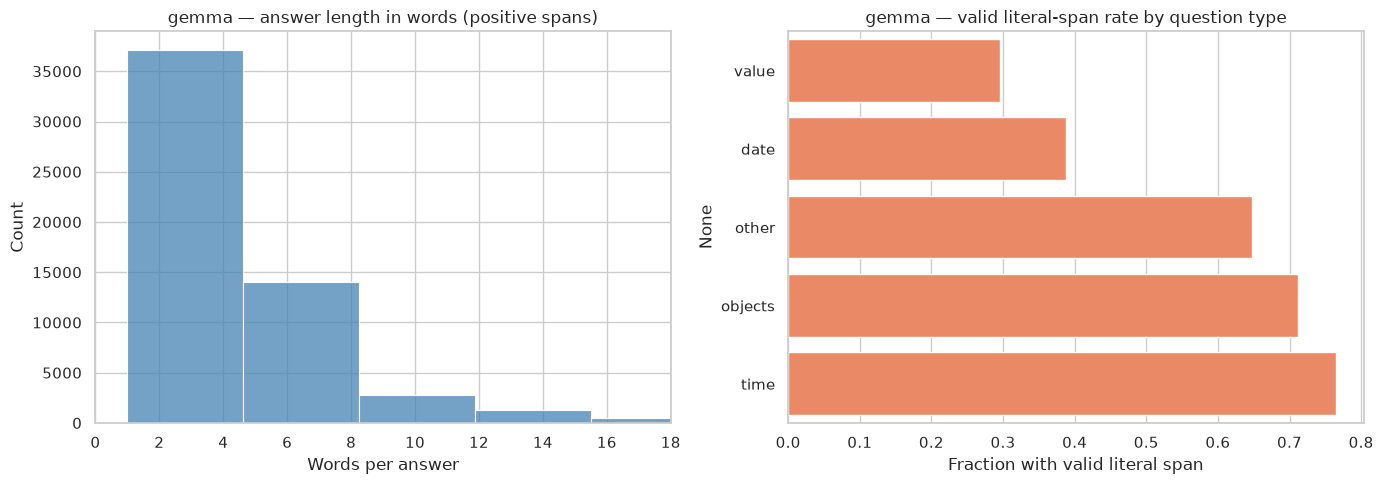

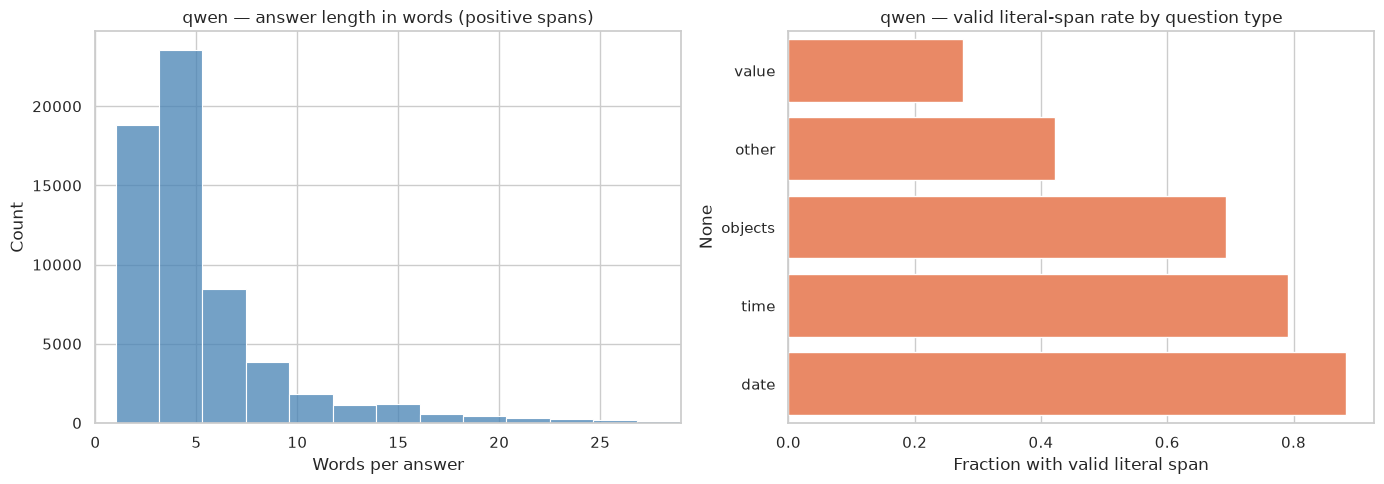

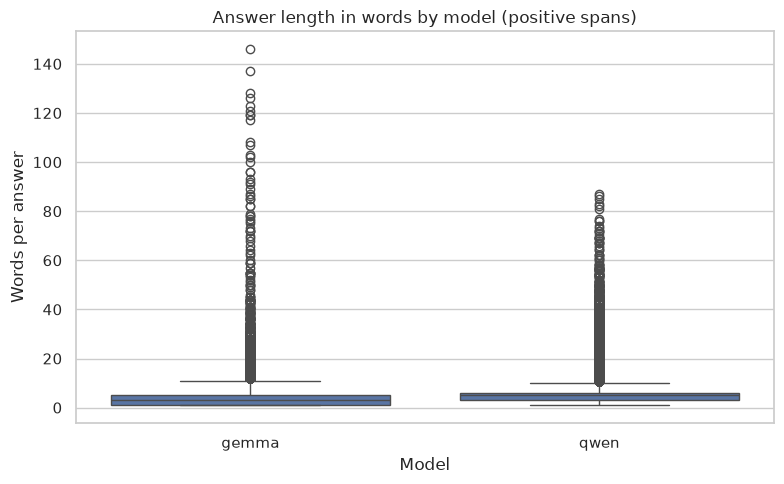

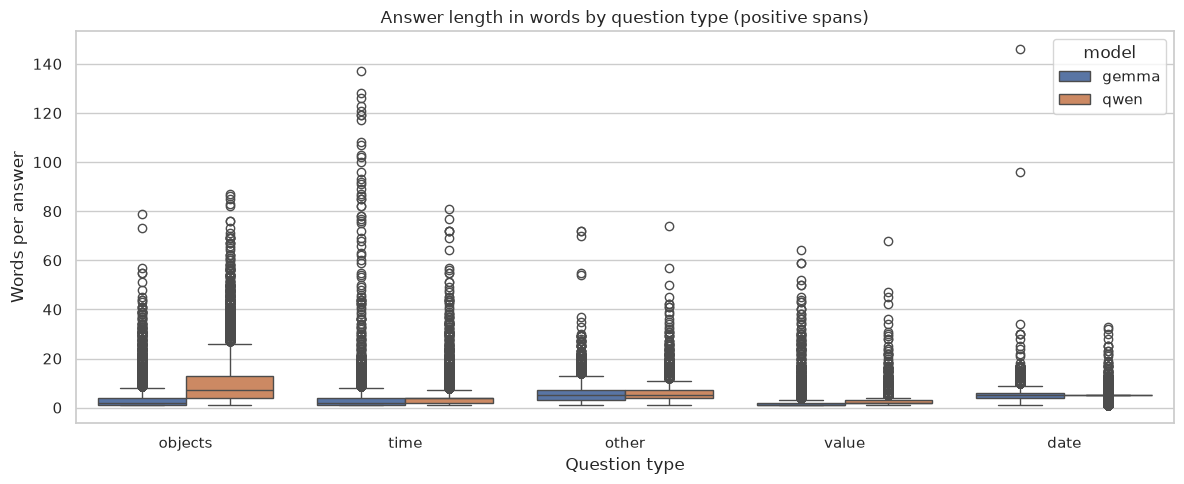

In [12]:
# Existing per-model plots: histogram + valid-span-rate barplot
for m in MODELS:
    df = frames[m]
    pos = df[df["literal_match"]]
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    # Answer length in words
    sns.histplot(pos["answer_words"], bins=40, ax=axes[0], color="steelblue")
    axes[0].set_title(f"{m} — answer length in words (positive spans)")
    axes[0].set_xlabel("Words per answer")
    axes[0].set_ylabel("Count")
    axes[0].set_xlim(0, np.percentile(pos["answer_words"], 99))
    # Valid literal-span rate by question type
    p = df.groupby("_qkind")["literal_match"].mean().sort_values()
    p.index = [QKIND_EN.get(i, i) for i in p.index]
    sns.barplot(x=p.values, y=p.index, ax=axes[1], color="coral")
    axes[1].set_title(f"{m} — valid literal-span rate by question type")
    axes[1].set_xlabel("Fraction with valid literal span")
    plt.tight_layout()
    fig.savefig(os.path.join(OUT_DIR, f"span_distribution_{m}.pdf"), bbox_inches="tight")
    fig.savefig(os.path.join(OUT_DIR, f"span_distribution_{m}.png"), bbox_inches="tight", dpi=200)
    plt.show()

# Comparative boxplot: Gemma vs Qwen
pos_all = pd.concat([
    frames[m][frames[m]["literal_match"]].assign(model=m)
    for m in MODELS
])
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=pos_all, x="model", y="answer_words", ax=ax)
ax.set_title("Answer length in words by model (positive spans)")
ax.set_xlabel("Model")
ax.set_ylabel("Words per answer")
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "boxplot_answer_words_by_model.pdf"), bbox_inches="tight")
fig.savefig(os.path.join(OUT_DIR, "boxplot_answer_words_by_model.png"), bbox_inches="tight", dpi=200)
plt.show()

# Boxplot by question type and model
pos_all["question_type"] = pos_all["_qkind"].map(QKIND_EN)
fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=pos_all, x="question_type", y="answer_words", hue="model", ax=ax)
ax.set_title("Answer length in words by question type (positive spans)")
ax.set_xlabel("Question type")
ax.set_ylabel("Words per answer")
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "boxplot_answer_words_by_question_type.pdf"), bbox_inches="tight")
fig.savefig(os.path.join(OUT_DIR, "boxplot_answer_words_by_question_type.png"), bbox_inches="tight", dpi=200)
plt.show()


## Phase 5 — Inter-generator agreement (Gemma vs Qwen)

Because both models processed the **same contexts** and the **same 5 questions**, we join on `(context_id, question)` and measure answerability agreement and exact-answer agreement. If only one model is present, this section is skipped.


### How to read the inter-generator agreement

- **Answerability agreement**: fraction of comparable `(context_id, question)` pairs where both models agree on whether a valid answer exists (both answered or both impossible).
- **Exact answer agreement (among both answered)**: among pairs where both models answered, the fraction that produced the same normalised span.
- **No-answer agreement**: fraction of all comparable pairs where both models abstained.
- **Disagreement rate**: fraction where one model answered and the other abstained.
- The four categories printed below are: `exact_answer_agreement`, `span_disagreement` (both answered but different spans), `no_answer_agreement` (both impossible), and `answerability_disagreement` (one answered, the other not).


In [13]:
if len(MODELS) == 2:
    a, b = MODELS
    cols = ["context_id","question","answer_text","is_impossible","literal_match","norm_match","qc_status","_qkind"]
    merged = frames[a][cols].merge(frames[b][cols], on=["context_id","question"],
                                   suffixes=(f"_{a}", f"_{b}"), how="inner")
    print("Comparable pairs:", len(merged))

    resp_a = merged[f"is_impossible_{a}"] == "respondido"
    resp_b = merged[f"is_impossible_{b}"] == "respondido"
    both_resp = resp_a & resp_b
    both_imp  = (~resp_a) & (~resp_b)
    answerability_agree = (both_resp | both_imp).mean()

    # exact answer agreement (same normalized span)
    def same_answer(r):
        return normalize_text(r[f"answer_text_{a}"]) == normalize_text(r[f"answer_text_{b}"]) and r[f"answer_text_{a}"].strip() != ""
    same_answers = progress_apply(merged, same_answer, axis=1, desc="same_answer agreement")
    exact_agree = same_answers[both_resp].mean() if both_resp.sum() else 0
    noanswer_agree = both_imp.mean()

    print(f"Answerability agreement: {answerability_agree*100:.2f}%")
    print(f"Exact answer agreement (among both answered): {exact_agree*100:.2f}%")
    print(f"No-answer agreement: {noanswer_agree*100:.2f}%")
    print(f"Disagreement rate: {(1-answerability_agree)*100:.2f}%")

    merged["agreement"] = np.where(both_resp & same_answers, "agree_exact",
                          np.where(both_resp, "disagree_span",
                          np.where(both_imp, "agree_no_answer", "disagree_answerability")))
    AGREEMENT_EN = {
        "agree_exact": "exact_answer_agreement",
        "disagree_span": "span_disagreement",
        "agree_no_answer": "no_answer_agreement",
        "disagree_answerability": "answerability_disagreement",
    }
    agreement_counts = merged["agreement"].value_counts().rename(index=AGREEMENT_EN)
    print(agreement_counts)
    merged.to_csv(os.path.join(OUT_DIR, f"agreement_{a}_{b}.csv"), index=False)
else:
    merged = None
    print("Only one model present — inter-generator agreement analysis skipped.")


Comparable pairs: 100000


same_answer agreement: 100%|██████████| 100000/100000 [00:05<00:00, 19583.26it/s]


Answerability agreement: 59.96%
Exact answer agreement (among both answered): 25.38%
No-answer agreement: 21.23%
Disagreement rate: 40.04%
agreement
answerability_disagreement    40039
span_disagreement             28901
no_answer_agreement           21229
exact_answer_agreement         9831
Name: count, dtype: int64


## Building the final datasets

We produce three sets per model (and, when applicable, a final merged dataset):

- **`strict`**: valid schema, consistent sentinel, positives with a single literal span and valid recomputed offset, without critical heuristic flags.
- **`expanded`**: valid in format/span or consistent no-answer; admits single-model cases and mild heuristic warnings.
- **`uncertain`**: malformed, inconsistent, non-extractive, ambiguous offset, disagreement, or heuristic suspicion.


In [14]:
SQUAD2_FIELDS = ["context_id","context","question","answer_text","answer_start","answer_end","impossible_find_answer","is_impossible"]

def to_squad2(row):
    '''Convert a validated record to final SQuAD v2 format.'''
    qid = f"{row['model']}_{row['context_id']}_{hash(row['question']) & 0xffffffff:x}"
    if row["is_impossible"] == "imposible":
        return {
            "id": qid,
            "context": row["context"],
            "question": row["question"],
            "is_impossible": True,
            "answers": {"text": [], "answer_start": []},
        }
    # valid answered: use recomputed offsets
    start = int(row["recomputed_answer_start"])
    end = start + len(row["answer_text"])
    return {
        "id": qid,
        "context": row["context"],
        "question": row["question"],
        "is_impossible": False,
        "answers": {"text": [row["answer_text"]], "answer_start": [start]},
    }

def build_splits(df, model):
    df = df.copy()
    df["model"] = model
    # --- strict ---
    # High-confidence positives + clean no-answer (sentinel) or non-extractive free text.
    strict_pos = (
        (df["is_impossible"] == "respondido") &
        (df["qc_status"] == "extractive_valid_unique") &
        (df["provided_offset_valid"]) &
        (~df["semantic_heuristic_flag"])
    )
    strict_no_ans = (
        (df["is_impossible"] == "imposible") &
        (df["qc_status"].isin(["no_answer_clean","no_answer_empty","no_answer_free_text"]))
    )
    strict_idx = strict_pos | strict_no_ans

    # --- expanded ---
    # Everything valid in format: positives with span (including ambiguous and normalized-only)
    # + all genuine no-answers (clean / free_text / empty).
    expanded_idx = df["qc_status"].isin([
        "extractive_valid_unique","extractive_ambiguous","extractive_only_normalized",
        "no_answer_clean","no_answer_empty","no_answer_free_text"
    ])
    uncertain_idx = ~strict_idx & ~expanded_idx

    strict = df[strict_idx].copy()
    expanded = df[expanded_idx].copy()
    uncertain = df[uncertain_idx].copy()
    return strict, expanded, uncertain

all_splits = {}
for m in MODELS:
    s, e, u = build_splits(frames[m], m)
    all_splits[m] = {"strict": s, "expanded": e, "uncertain": u}
    print(f"=== {m} ===")
    print(f"strict: {len(s)} | expanded: {len(e)} | uncertain: {len(u)}")
    # save SQuAD v2
    for name, sub in [("strict", s), ("expanded", e)]:
        out = os.path.join(OUT_DIR, f"squadv2_{name}_{m}.jsonl")
        with open(out, "w", encoding="utf-8") as f:
            for _, r in tqdm(sub.iterrows(), total=len(sub), desc=f"writing {name}_{m}", unit="rows"):
                f.write(json.dumps(to_squad2(r), ensure_ascii=False) + "\n")
        print(f"  saved: {out} ({len(sub)} records)")
    all_splits[m]["uncertain"].to_csv(os.path.join(OUT_DIR, f"uncertain_{m}.csv"), index=False)
    print()


=== gemma ===
strict: 79312 | expanded: 99999 | uncertain: 1


writing strict_gemma: 100%|██████████| 79312/79312 [00:17<00:00, 4549.66rows/s]


  saved: out_qc_M2/squadv2_strict_gemma.jsonl (79312 records)


writing expanded_gemma: 100%|██████████| 99999/99999 [00:21<00:00, 4681.15rows/s]


  saved: out_qc_M2/squadv2_expanded_gemma.jsonl (99999 records)

=== qwen ===
strict: 85042 | expanded: 100000 | uncertain: 0


writing strict_qwen: 100%|██████████| 85042/85042 [00:15<00:00, 5584.90rows/s]


  saved: out_qc_M2/squadv2_strict_qwen.jsonl (85042 records)


writing expanded_qwen: 100%|██████████| 100000/100000 [00:21<00:00, 4652.52rows/s]

  saved: out_qc_M2/squadv2_expanded_qwen.jsonl (100000 records)



### Final merged dataset (best answers from both models)

When both models are available, we combine high-confidence answers:
- If both return the same span (normalized), it is kept.
- If both return no-answer, it is kept as unanswerable.
- In disagreement, the unique valid span without heuristic flags is preferred.


In [15]:
if len(MODELS) == 2 and merged is not None:
    a, b = MODELS
    fa, fb = frames[a], frames[b]
    cols = ["context_id","question","context","answer_text","answer_start","answer_end",
            "impossible_find_answer","is_impossible","literal_match","recomputed_answer_start",
            "provided_offset_valid","semantic_heuristic_flag","qc_status","_qkind"]
    mm = fa[cols].merge(fb[cols], on=["context_id","question","context"],
                        suffixes=(f"_{a}", f"_{b}"), how="inner")

    def pick_final(r):
        # no-answer agreement
        if r[f"is_impossible_{a}"]=="imposible" and r[f"is_impossible_{b}"]=="imposible":
            return pd.Series({**r[["context_id","context","question"]], "model":"both",
                              "is_impossible":"imposible","answer_text":NO_ANSWER_SENTINEL,
                              "recomputed_answer_start":-1})
        # exact agreement
        if normalize_text(r[f"answer_text_{a}"]) == normalize_text(r[f"answer_text_{b}"]) and r[f"answer_text_{a}"].strip()!="":
            base = a if r[f"provided_offset_valid_{a}"] else b
            return pd.Series({**r[["context_id","context","question"]], "model":base,
                              "is_impossible":"respondido","answer_text":r[f"answer_text_{base}"],
                              "recomputed_answer_start":r[f"recomputed_answer_start_{base}"]})
        # prefer unique valid span without heuristic flag
        for base in (a, b):
            if (r[f"is_impossible_{base}"]=="respondido" and
                r[f"qc_status_{base}"]=="extractive_valid_unique" and
                r[f"provided_offset_valid_{base}"] and
                not r[f"semantic_heuristic_flag_{base}"]):
                return pd.Series({**r[["context_id","context","question"]], "model":base,
                                  "is_impossible":"respondido","answer_text":r[f"answer_text_{base}"],
                                  "recomputed_answer_start":r[f"recomputed_answer_start_{base}"]})
        return pd.Series({**r[["context_id","context","question"]], "model":"uncertain",
                          "is_impossible":"imposible","answer_text":NO_ANSWER_SENTINEL,
                          "recomputed_answer_start":-1})

    final = progress_apply(mm, pick_final, axis=1, desc="pick_final (merged)")
    final = final[final["model"]!="uncertain"].reset_index(drop=True)
    out = os.path.join(OUT_DIR, "squadv2_final_merged.jsonl")
    with open(out, "w", encoding="utf-8") as f:
        for _, r in tqdm(final.iterrows(), total=len(final), desc="writing merged", unit="rows"):
            f.write(json.dumps(to_squad2({**r, "model":"merged"}), ensure_ascii=False) + "\n")
    FINAL_MODEL_EN = {"both": "both (no-answer agreement)", "gemma": "gemma (preferred)", "qwen": "qwen (preferred)"}
    print(f"Merged final dataset: {len(final)} records -> {out}")
    final_counts = final["model"].value_counts().rename(index=FINAL_MODEL_EN)
    print(final_counts)
else:
    print("Only one model present — no merged dataset built.")
    # use strict of gemma as final
    if MODELS:
        m = MODELS[0]
        print(f"Final dataset = strict of {m}: {len(all_splits[m]['strict'])} records")


writing merged: 100%|██████████| 80726/80726 [00:21<00:00, 3831.21rows/s]


Merged final dataset: 80726 records -> out_qc_M2/squadv2_final_merged.jsonl
model
gemma (preferred)             37434
qwen (preferred)              22063
both (no-answer agreement)    21229
Name: count, dtype: int64


### Can the merged dataset be used for fine-tuning?

The merged `squadv2_final_merged.jsonl` is SQuAD v2 formatted: answered rows contain one literal span with recomputed offsets; abstentions have `is_impossible: true` and empty answers. It can be used as a starting point for fine-tuning an extractive QA model (e.g. BETO/BERT-Spanish), with these caveats:

- It is a **curated subset** of the original 75,000 pairs (only high-confidence or agreed cases), so report its size and composition.
- Split it into train/dev/test **before** training, ideally stratified by source context/report.
- The 200-row stratified audit should be labelled by a human to estimate error rates before trusting the auto-generated labels.
- Because exact inter-model agreement is low (~25% among answered pairs), monitor EM/F1 on a held-out human-verified set rather than assuming the merged labels are ground truth.


## Stratified human audit

Generates a stratified random sample ready for manual review. Target size: ~200–300 examples, with an approximate margin of ±5–7 percentage points at 95% confidence.


In [16]:
AUDIT_N = 250

def stratified_audit(df, model, n):
    pos = df[df["literal_match"]].copy()
    flags = df[df["semantic_heuristic_flag"]].copy()
    nonext = df[df["qc_status"]=="non_extractive_or_hallucinated"].copy()
    noans = df[df["is_impossible"]=="imposible"].copy()
    parts = []
    def sample_from(sub, k):
        k = min(k, len(sub))
        return sub.sample(k, random_state=42) if k > 0 else pd.DataFrame()
    parts.append(sample_from(pos[~pos["semantic_heuristic_flag"]], max(1, int(n*0.40))))
    parts.append(sample_from(noans, max(1, int(n*0.20))))
    parts.append(sample_from(flags, max(1, int(n*0.20))))
    parts.append(sample_from(df[df["qc_status"]=="non_extractive_or_hallucinated"], max(1, int(n*0.10))))
    parts.append(sample_from(df[df["qc_status"]=="imposible_but_span_present"], max(1, int(n*0.10))))
    out = pd.concat(parts).drop_duplicates(subset=["context_id","question"]).head(n)
    out = out[["context_id","question","answer_text","context","is_impossible",
              "qc_status","semantic_heuristic_flag","literal_match","recomputed_answer_start"]].copy()
    out.insert(0, "model", model)
    out.insert(0, "human_label", "")
    out.insert(0, "notes", "")
    return out

audit_parts = [stratified_audit(frames[m], m, AUDIT_N // len(MODELS)) for m in MODELS]
audit = pd.concat(audit_parts).reset_index(drop=True)
audit_path = os.path.join(OUT_DIR, "audit_stratified_sample.csv")
audit.to_csv(audit_path, index=False)
print(f"Audit sample: {len(audit)} records -> {audit_path}")
audit["model"].value_counts()


Audit sample: 201 records -> out_qc_M2/audit_stratified_sample.csv


model
gemma    101
qwen     100
Name: count, dtype: int64

## Worker time analysis

Worker logs contain `it/s` progress lines and checkpoints. We extract the total time per worker for Gemma and Qwen, tagging each log with its segment (`initial` or a resume subdirectory) so interrupted/resumed runs are handled correctly for either model. We report per-segment and global GPU-hours, s/context, and wall-clock estimates. This is process diagnostics, not dataset quality.


In [17]:
def parse_worker_logs(logs_dir, patterns):
    """Parse worker logs for every model, tagging each row with its segment.

    A segment is either "initial" (logs in the root of logs_dir) or the name
    of a resume subdirectory (e.g. "resume_20260829_222800"). This supports
    any model being interrupted and resumed one or more times.
    """
    rows = []
    for model, pat_list in patterns.items():
        if isinstance(pat_list, str):
            pat_list = [pat_list]
        for pattern in pat_list:
            for path in sorted(glob.glob(os.path.join(logs_dir, pattern))):
                with open(path, "r", encoding="utf-8", errors="ignore") as f:
                    text = f.read()
                rel = os.path.relpath(path, logs_dir)
                parts = rel.split(os.sep)
                segment = "initial" if len(parts) == 1 else parts[0]
                worker = os.path.basename(path)
                # last progress line, e.g. 3747/3750 [10:20:48<00:31
                prog = re.findall(r"(\d+)/(\d+)\s*\[(\d+):(\d+):(\d+)<", text)
                total_sec = None
                done = 0
                target = None
                if prog:
                    done = int(prog[-1][0]); target = int(prog[-1][1])
                    h, mn, s = int(prog[-1][2]), int(prog[-1][3]), int(prog[-1][4])
                    total_sec = h*3600 + mn*60 + s
                n_errors = text.count("Error crítico")
                n_fallback = text.lower().count("fallback")
                n_checkpoints = text.count("Checkpoint guardado")
                seconds_per_context = (total_sec / done) if total_sec and done else None
                rows.append({
                    "model": model, "segment": segment, "worker": worker,
                    "processed": done, "target": target,
                    "fallbacks": n_fallback, "critical_errors": n_errors,
                    "checkpoints": n_checkpoints, "total_seconds": total_sec,
                    "seconds_per_context": seconds_per_context,
                })
    return pd.DataFrame(rows)

patterns = {m: WORKER_LOG_PATTERNS[m] for m in MODELS if m in WORKER_LOG_PATTERNS}
logs = parse_worker_logs(WORKER_LOG_DIR, patterns)
if len(logs) == 0:
    print(f"No worker logs found in {WORKER_LOG_DIR}. Skipping time analysis.")
else:
    print("Parsed worker logs:")
    print(logs.to_string(index=False))
    print("\nSummary by model and segment:")
    for model, sub in logs.groupby("model"):
        print(f"\n=== {model} ===")
        seg_summary = sub.groupby("segment").agg(
            workers=("worker", "count"),
            processed=("processed", "sum"),
            elapsed_seconds=("total_seconds", "sum"),
            fallbacks=("fallbacks", "sum"),
            critical_errors=("critical_errors", "sum"),
            checkpoints=("checkpoints", "sum"),
        ).reset_index()
        seg_summary["gpu_hours"] = seg_summary["elapsed_seconds"] / 3600
        seg_summary["seconds_per_context"] = (
            seg_summary["elapsed_seconds"] / seg_summary["processed"].replace(0, np.nan)
        )
        print(seg_summary.to_string(index=False))

        total_processed = int(sub["processed"].sum())
        total_seconds = sub["total_seconds"].sum()
        gpu_hours = total_seconds / 3600
        mean_spc = total_seconds / total_processed if total_processed else float("nan")
        print(f"\nGlobal: processed={total_processed} | "
              f"GPU-hours={gpu_hours:.2f} | mean s/context={mean_spc:.2f}")

        for segment, ssub in sub.groupby("segment"):
            sec = ssub["total_seconds"].dropna()
            if len(sec):
                print(f"  segment '{segment}': workers={len(ssub)} "
                      f"wall-clock(max)={sec.max()/3600:.2f} h")

        # Continuous-run estimate with a fixed number of workers (adjust as needed).
        fixed_workers = max(sub.groupby("segment")["worker"].count().max(), 1)
        print(f"Continuous wall-clock estimate with {fixed_workers} workers: "
              f"{total_seconds/fixed_workers/3600:.2f} h")

        print("Time per worker (HH:MM:SS):")
        for _, r in sub.sort_values(["segment", "worker"]).iterrows():
            ts = r["total_seconds"]
            if pd.notna(ts):
                s = int(ts)
                print(f"  [{r['segment']}] {r['worker']}: "
                      f"{s//3600:02d}:{(s%3600)//60:02d}:{s%60:02d} "
                      f"({r['processed']} processed)")


Parsed worker logs:
model                              segment                           worker  processed  target  fallbacks  critical_errors  checkpoints  total_seconds  seconds_per_context
gemma                              initial       gemma-3-1b-it_worker_0.log       3045    5000         13                9           14          61803            20.296552
gemma                              initial       gemma-3-1b-it_worker_1.log       3078    5000         31               13           21          61812            20.081871
gemma                              initial       gemma-3-1b-it_worker_2.log       3112    5000         31               19           22          61810            19.861825
gemma                              initial       gemma-3-1b-it_worker_3.log       3050    5000         14               10           11          61811            20.265902
gemma gemma-3-1b-it_resume_20260829_222800       gemma-3-1b-it_worker_0.log        965     965         13               

## Summary of metrics for the paper

Consolidated table by model. These metrics support the Gemma vs Qwen comparison and the quality of the final dataset. Key tables are exported as `.tex` in the next cell.


In [18]:
def metrics_table(m):
    df = frames[m]
    n = len(df)
    pos = df[df["is_impossible"]=="respondido"]
    return {
        "contexts_processed": N_CONTEXTS,
        "questions_per_context": QUESTIONS_PER_CONTEXT,
        "expected_pairs": EXPECTED_PAIRS,
        "generated_pairs": n,
        "completeness_%": round(n/EXPECTED_PAIRS*100, 2),
        "answer_rate_%": round((df["is_impossible"]=="respondido").mean()*100, 2),
        "abstention_rate_%": round((df["is_impossible"]=="imposible").mean()*100, 2),
        "literal_span_valid_%": round(df["literal_match"].mean()*100, 2),
        "provided_offset_valid_%": round(df["provided_offset_valid"].mean()*100, 2),
        "non_extractive_%": round((df["qc_status"]=="non_extractive_or_hallucinated").mean()*100, 2),
        "inconsistent_sentinel": int(((df["is_impossible"]=="imposible") & (df["answer_text"]!=NO_ANSWER_SENTINEL)).sum()),
        "strict_n": len(all_splits[m]["strict"]),
        "expanded_n": len(all_splits[m]["expanded"]),
        "uncertain_n": len(all_splits[m]["uncertain"]),
        "heuristic_flags": int(df["semantic_heuristic_flag"].sum()),
        "mean_answer_words": round(pos["answer_words"].mean(), 2) if len(pos) else 0,
    }

# Vertical table: metrics as rows, models as columns (publication-friendly)
summary = pd.DataFrame({m: metrics_table(m) for m in MODELS})
summary_path = os.path.join(OUT_DIR, "metrics_summary.csv")
summary.to_csv(summary_path)
summary


,gemma,qwen
contexts_processed,20000.00,20000.00
questions_per_context,5.00,5.00
expected_pairs,100000.00,100000.00
generated_pairs,100000.00,100000.00
completeness_%,100.00,100.00
answer_rate_%,56.16,61.34
abstention_rate_%,43.84,38.66
literal_span_valid_%,56.16,61.34
provided_offset_valid_%,56.09,61.34
non_extractive_%,0.00,0.00


In [19]:
# ------------------------------------------------------------------
# Export publication tables to LaTeX (.tex)
# ------------------------------------------------------------------
def export_latex(df, name, caption, label):
    tex = df.to_latex(
        float_format="%.2f",
        caption=caption,
        label=label,
        position="ht",
        column_format="l" + "r" * len(df.columns),
    )
    path = os.path.join(OUT_DIR, f"{name}.tex")
    with open(path, "w", encoding="utf-8") as f:
        f.write(tex)
    print(f"Saved: {path}")

export_latex(struct_summary, "table_struct_summary", "Structural integrity summary by model", "tab:struct")
export_latex(abst, "table_abstention", "Abstention consistency by model", "tab:abstention")
export_latex(summary, "table_metrics_summary", "Consolidated QC metrics by model", "tab:metrics")

# Answer/abstention rate by question type (models as column blocks)
pivot_frames = {}
for m in MODELS:
    pivot = frames[m].groupby(["_qkind", "is_impossible"]).size().unstack(fill_value=0)
    pivot_pct = (pivot.div(pivot.sum(axis=1), axis=0) * 100).round(1)
    pivot_pct = pivot_pct.rename(columns={"imposible": "impossible", "respondido": "answered"})
    pivot_pct.index = [QKIND_EN.get(i, i) for i in pivot_pct.index]
    pivot_pct.index.name = "question_type"
    pivot_frames[m] = pivot_pct
pivot_combined = pd.concat(pivot_frames, axis=1)
export_latex(pivot_combined, "table_answer_rate_by_question_type", "Answer/abstention rate by question type (%)", "tab:qtype")

if len(MODELS) == 2 and merged is not None:
    agreement_table = pd.DataFrame({
        "metric": [
            "Comparable pairs",
            "Answerability agreement (%)",
            "Exact answer agreement among answered (%)",
            "No-answer agreement (%)",
            "Disagreement rate (%)",
        ],
        "value": [
            len(merged),
            answerability_agree * 100,
            exact_agree * 100,
            noanswer_agree * 100,
            (1 - answerability_agree) * 100,
        ],
    }).set_index("metric")
    export_latex(agreement_table, "table_agreement", "Inter-generator agreement", "tab:agreement")

    final_counts = final["model"].value_counts().rename(index=FINAL_MODEL_EN).to_frame("records")
    export_latex(final_counts, "table_merged_composition", "Merged dataset composition", "tab:merged")


Saved: out_qc_M2/table_struct_summary.tex
Saved: out_qc_M2/table_abstention.tex
Saved: out_qc_M2/table_metrics_summary.tex
Saved: out_qc_M2/table_answer_rate_by_question_type.tex
Saved: out_qc_M2/table_agreement.tex
Saved: out_qc_M2/table_merged_composition.tex


## Conclusions and next steps

1. **Do not trust generated offsets**: always recompute and validate them against the context.
2. **The sentinel is removed from the final dataset** and converted to `is_impossible: true`.
3. **An answer that does not appear in the context is not converted to `imposible`**: it is marked as `non_extractive_or_hallucinated` and goes to `uncertain`.
4. The semantic heuristic by question type detects cases such as `aproximadamente` answering "what time?". It flags, it does not delete.
5. The stratified human audit (~250 examples) allows estimating real quality with confidence intervals, without reviewing all 75,000 pairs.

**Next steps**: run this notebook on the Qwen JSONL (when available), compare metrics, and train BETO/QA on `strict` vs `expanded`, evaluating EM and F1 on a fixed test set separated by source report.


## Limitations

- **Auto-generated labels are not ground truth**: the pipeline validates structure and span literality, not semantic correctness. The human audit sample must be labelled before using the data for training.
- **Low inter-model agreement**: exact answer agreement between Gemma and Qwen is low (~25% among answered pairs); the merged dataset is a curated subset and may carry systematic errors from both models.
- **Heuristic thresholds**: the 30-word limit and the semantic heuristics are editorial choices, not statistically derived criteria.
- **Completeness below 100%**: generation/merge produced fewer than the 75,000 expected pairs per model; the missing rows are excluded from analysis and final datasets.
- **Publication tables are exports of the notebook state**: re-run the notebook after any data or code change so `.tex`, PDFs, and CSVs are consistent.
